In [112]:
using Piccolo
using LinearAlgebra
using CairoMakie

In [230]:
δ = -0.4

a = annihilate(3)

#sys = QuantumSystem(δ / 2 * a' * a' * a * a, [(a + a')/2, -im * (a - a') / 2], [0.5,0.5])

sys = TransmonSystem(levels = 3, δ = δ, drive_bounds = [0.5, 0.5], multiply_by_2π = false)

QuantumSystem: levels = 3, n_drives = 2

In [231]:
U_goal = EmbeddedOperator(:X, sys)

EmbeddedOperator{ComplexF64}(ComplexF64[0.0 + 0.0im 1.0 + 0.0im 0.0 + 0.0im; 1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im], [1, 2], [3])

In [238]:
const super_duper_value = 0.598144006661 # integral from -1/2 to 1/2 of e^(-8u^2)
λ = √2
Δ = - 2π * 400 / 1000

function gaussian_curve(T, N)
    A = π / (T * (super_duper_value - ℯ^(-2))) / 2
    μ = T / 2
    σ = T / 4

    times = collect(range(0, T, length = N))
    
    function f(t)
        return A * (ℯ^(-(t - μ)^2 / (2σ^2)) - ℯ^(-2))
    end

    function f_prime(t)
        return A * ℯ^(-(t - μ)^2 / (2σ^2)) * ((μ - t)/σ^2)
    end

    println(sum((f.(times[1:end-1]) + f.(times[2:end]))/2) * T / N)
    println(f(times[1]))
    println(f(times[end]))

    E_π = f.(times)
    Ė_π = f_prime.(times)
    return times, E_π, Ė_π
end

function drag_gaussian(T, N)
    times, E_π, Ė_π = gaussian_curve(T, N)
    E_x = E_π .+ ((λ^2-4)/(8Δ^2) * E_π .^ 3) - ((13λ^4 - 76λ^2 + 112) / 128Δ^4 * E_π .^ 5)
    E_y = -Ė_π ./ Δ + ((33(λ^2-2)/24Δ^3) * E_π .^2 .* Ė_π)
    return times, E_x, E_y
end

drag_gaussian (generic function with 1 method)

In [239]:
T = 20.0
N = 200

controls = zeros(2, N)

times, gaussian, _ = gaussian_curve(T, N)

controls[1, :] .= gaussian

pulse = ZeroOrderPulse(controls, times)

1.5629269571641078
0.0
0.0


ZeroOrderPulse
  drives: 2
  duration: 20.0

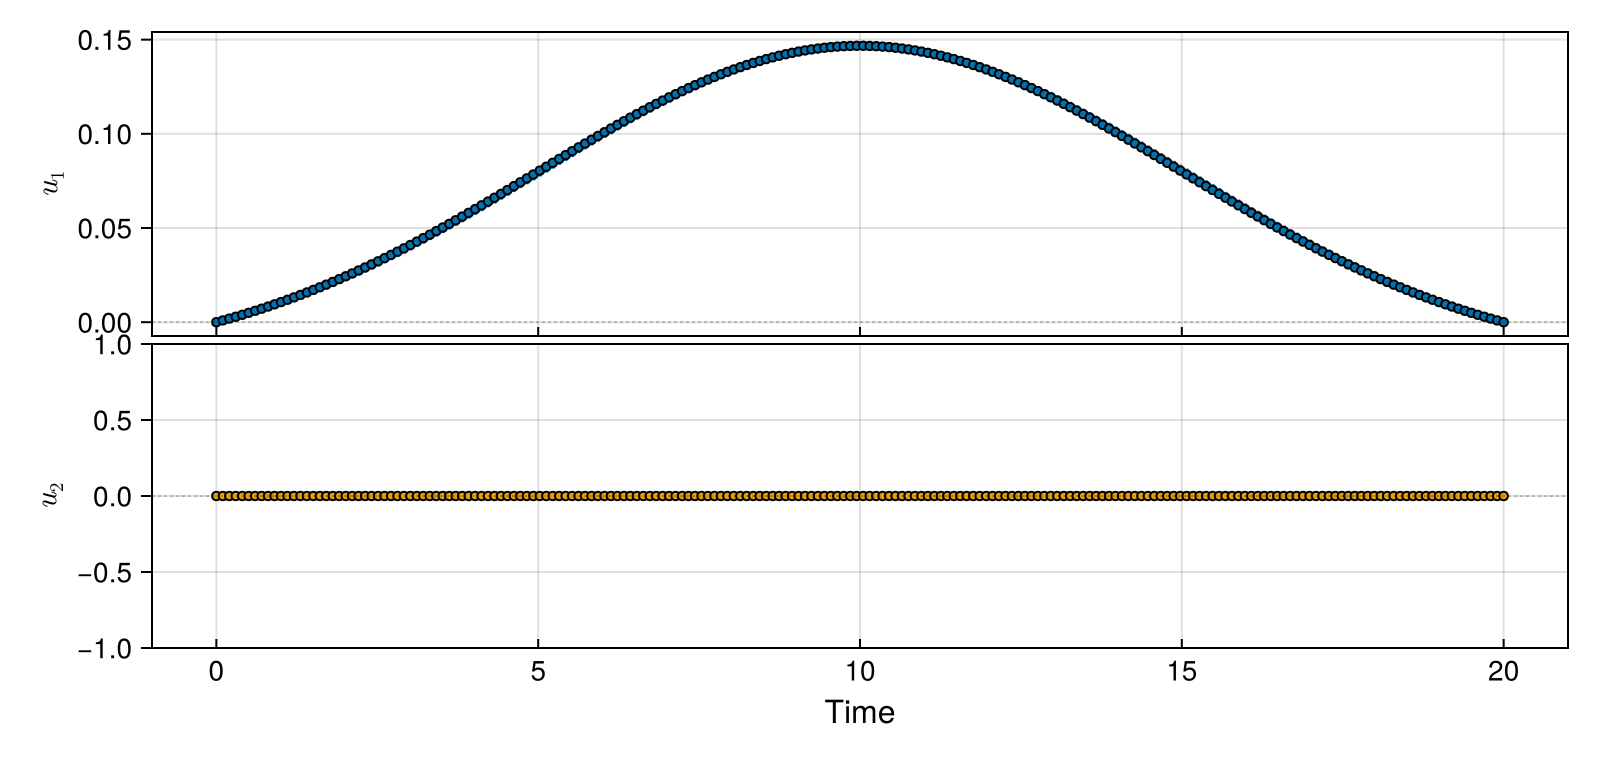

In [240]:
plot_pulse(pulse)

In [241]:
traj = UnitaryTrajectory(sys, pulse, U_goal)
out = rollout(traj)
println(1 - fidelity(out))

0.15357675230669787


In [242]:
qcp = SmoothPulseProblem(traj, N)

constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=200   T=20.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.5, 0.5]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 15.36  @ current x
│    KnotPointObjective           w=1             15.36
│    QuadraticRegularizer(:u)     w=1             8.609e-05
│    QuadraticRegularizer(:du)    w=1             2.451e-06
│    QuadraticRegularizer(:ddu)   w=1             1.379e-07
│    NullObjective                w=1 

QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=200   T=20.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.5, 0.5]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 15.36  @ current x
│    KnotPointObjective           w=1             15.36
│    QuadraticRegularizer(:u)     w=1             8.609e-05
│    QuadraticRegularizer(:du)    w=1             2.451e-06
│    QuadraticRegularizer(:ddu)   w=1             1.379e-07
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at 

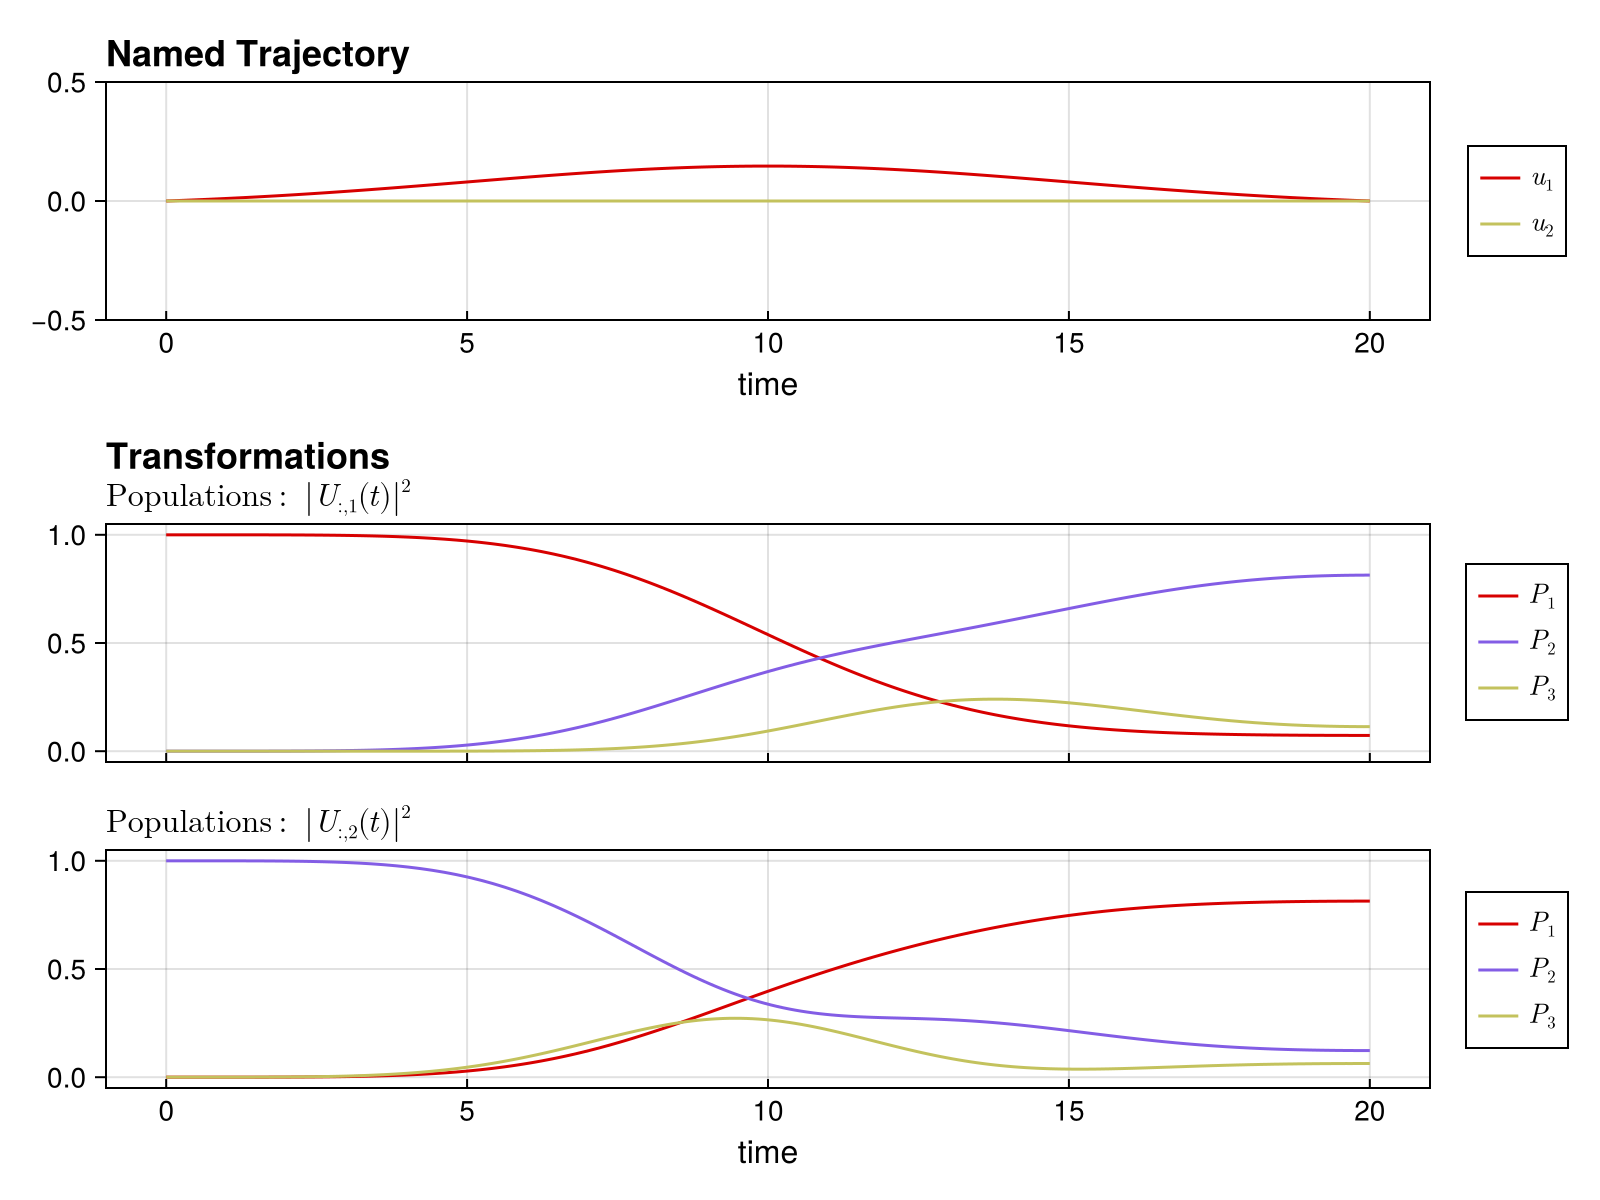

In [243]:
plot_unitary_populations(get_trajectory(qcp))

In [214]:
controls = zeros(2, N)

times, controls[1, :], controls[2, :] = drag_gaussian(T, N)

pulse = ZeroOrderPulse(controls, times)

3.1258539143282156
0.0
0.0


ZeroOrderPulse
  drives: 2
  duration: 20.0

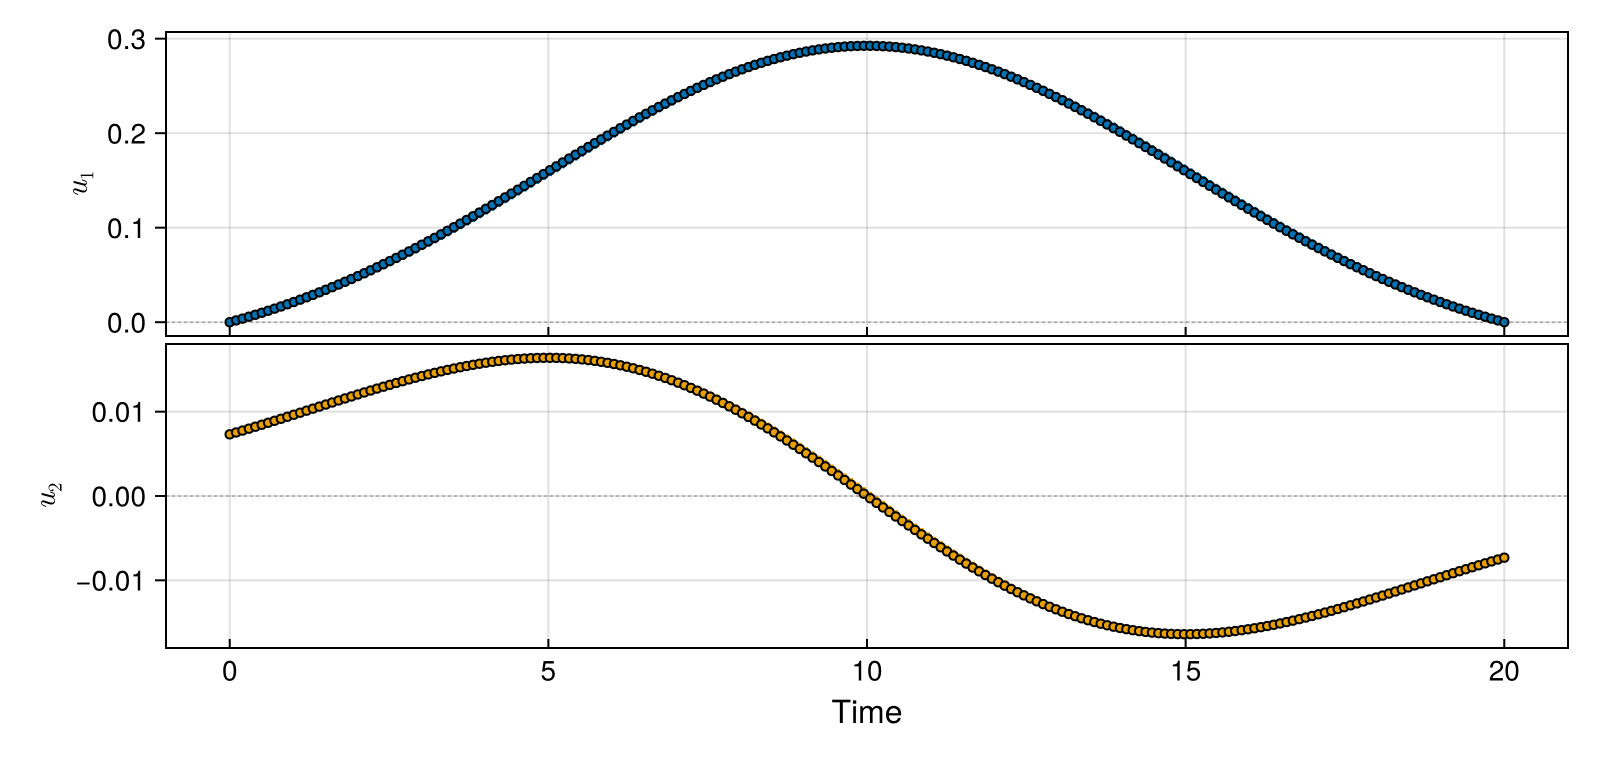

In [215]:
plot_pulse(pulse)

In [216]:
traj = UnitaryTrajectory(sys, pulse, U_goal)
out = rollout(traj)
println(1 - fidelity(out))

0.09428687007759073


In [217]:
qcp = SmoothPulseProblem(traj, N)

constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=200   T=20.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.5, 0.5]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 9.429  @ current x
│    KnotPointObjective           w=1             9.429
│    QuadraticRegularizer(:u)     w=1             3.442e-04
│    QuadraticRegularizer(:du)    w=1             9.830e-06
│    QuadraticRegularizer(:ddu)   w=1             5.549e-07
│    NullObjective                w=1 

QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=3   drives=2
│  
├─ Trajectory
│    N=200   T=20.000   Δt∈[0, Inf]
│    Ũ⃗    (18)  ±[1.0, 1.0, 1.0, … (18 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.5, 0.5]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [3], subspace dim 2
│  
├─ Objective   total = 9.429  @ current x
│    KnotPointObjective           w=1             9.429
│    QuadraticRegularizer(:u)     w=1             3.442e-04
│    QuadraticRegularizer(:du)    w=1             9.830e-06
│    QuadraticRegularizer(:ddu)   w=1             5.549e-07
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at 

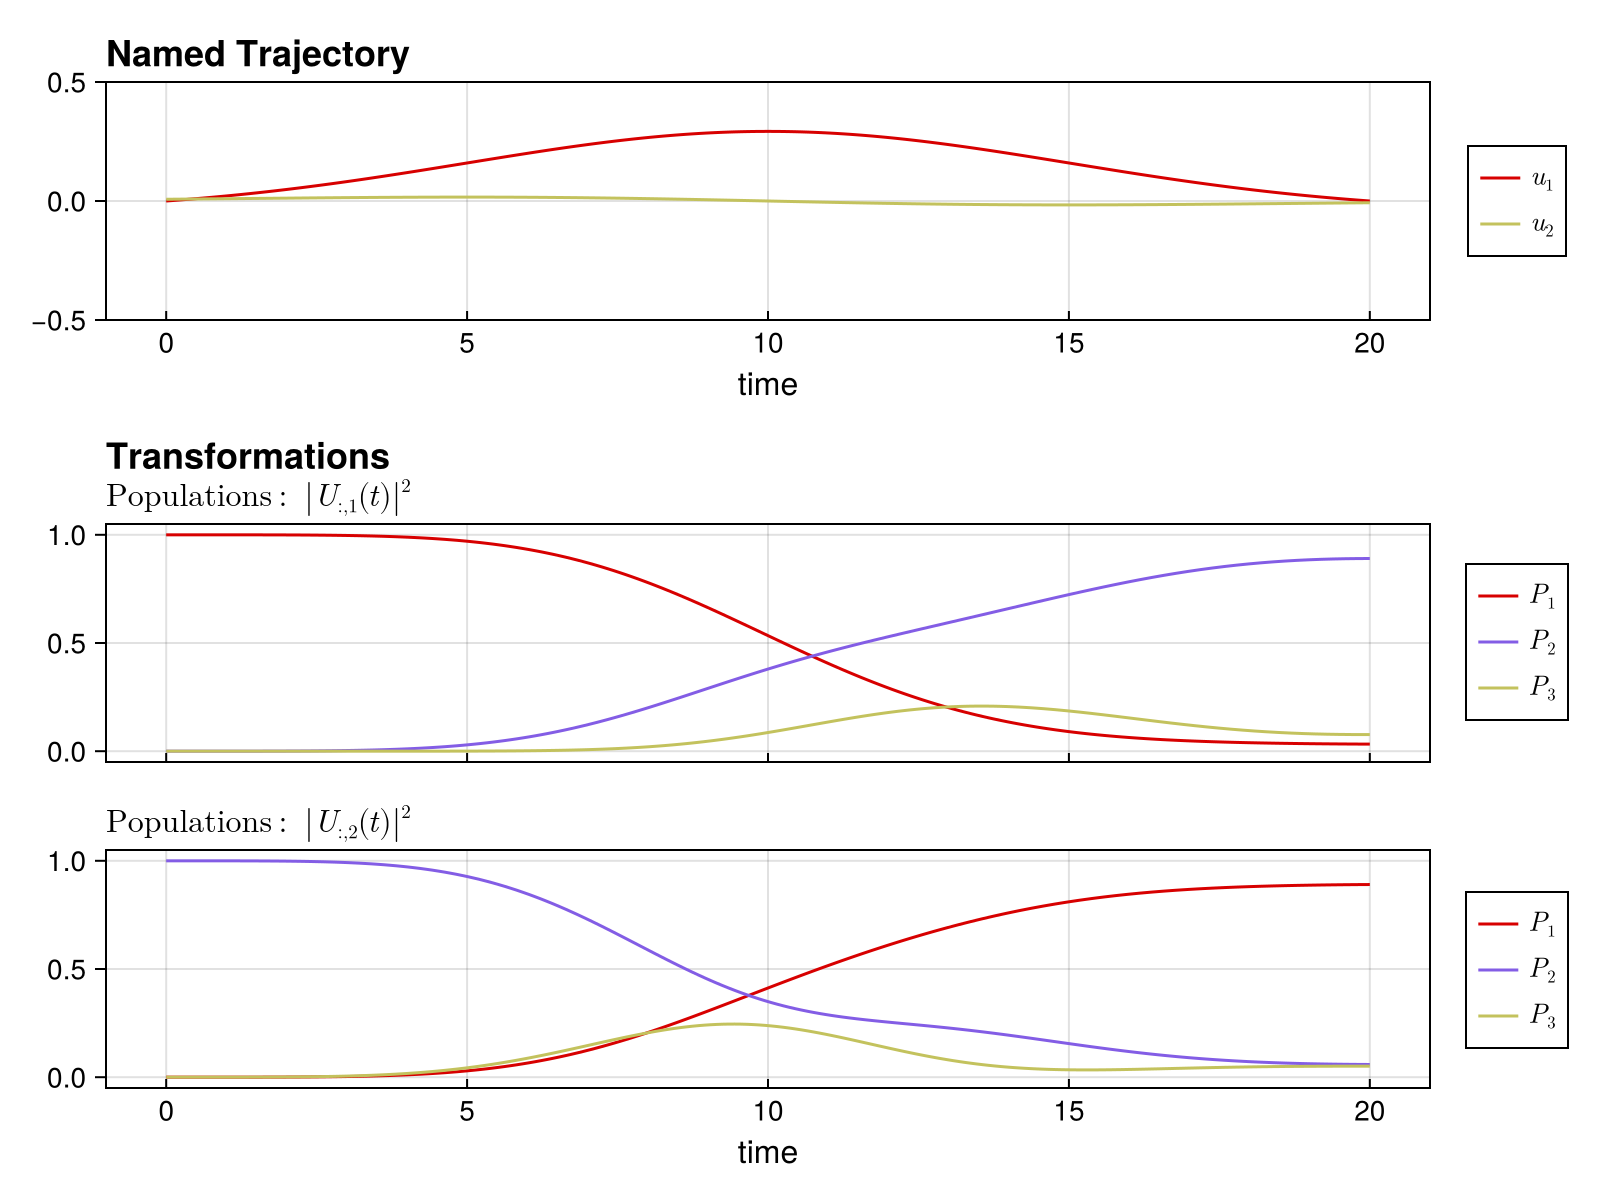

In [218]:
plot_unitary_populations(get_trajectory(qcp))

In [220]:
solve!(qcp; max_iter=100, eval_hessian = false)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.9.0.

Number of nonzeros in equality constraint Jacobian...:   227746
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     5177
                     variables with only lower bounds:      200
                variables with lower and upper bounds:     4378
                     variables with only upper bounds:        0
Total number of equality constraints.................:     4577
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.0409844e-04 1.00e-02 1.00e+00   0.0 0.00e+00    -  0.00e+00 0.00e+00 

0.9999998168326398


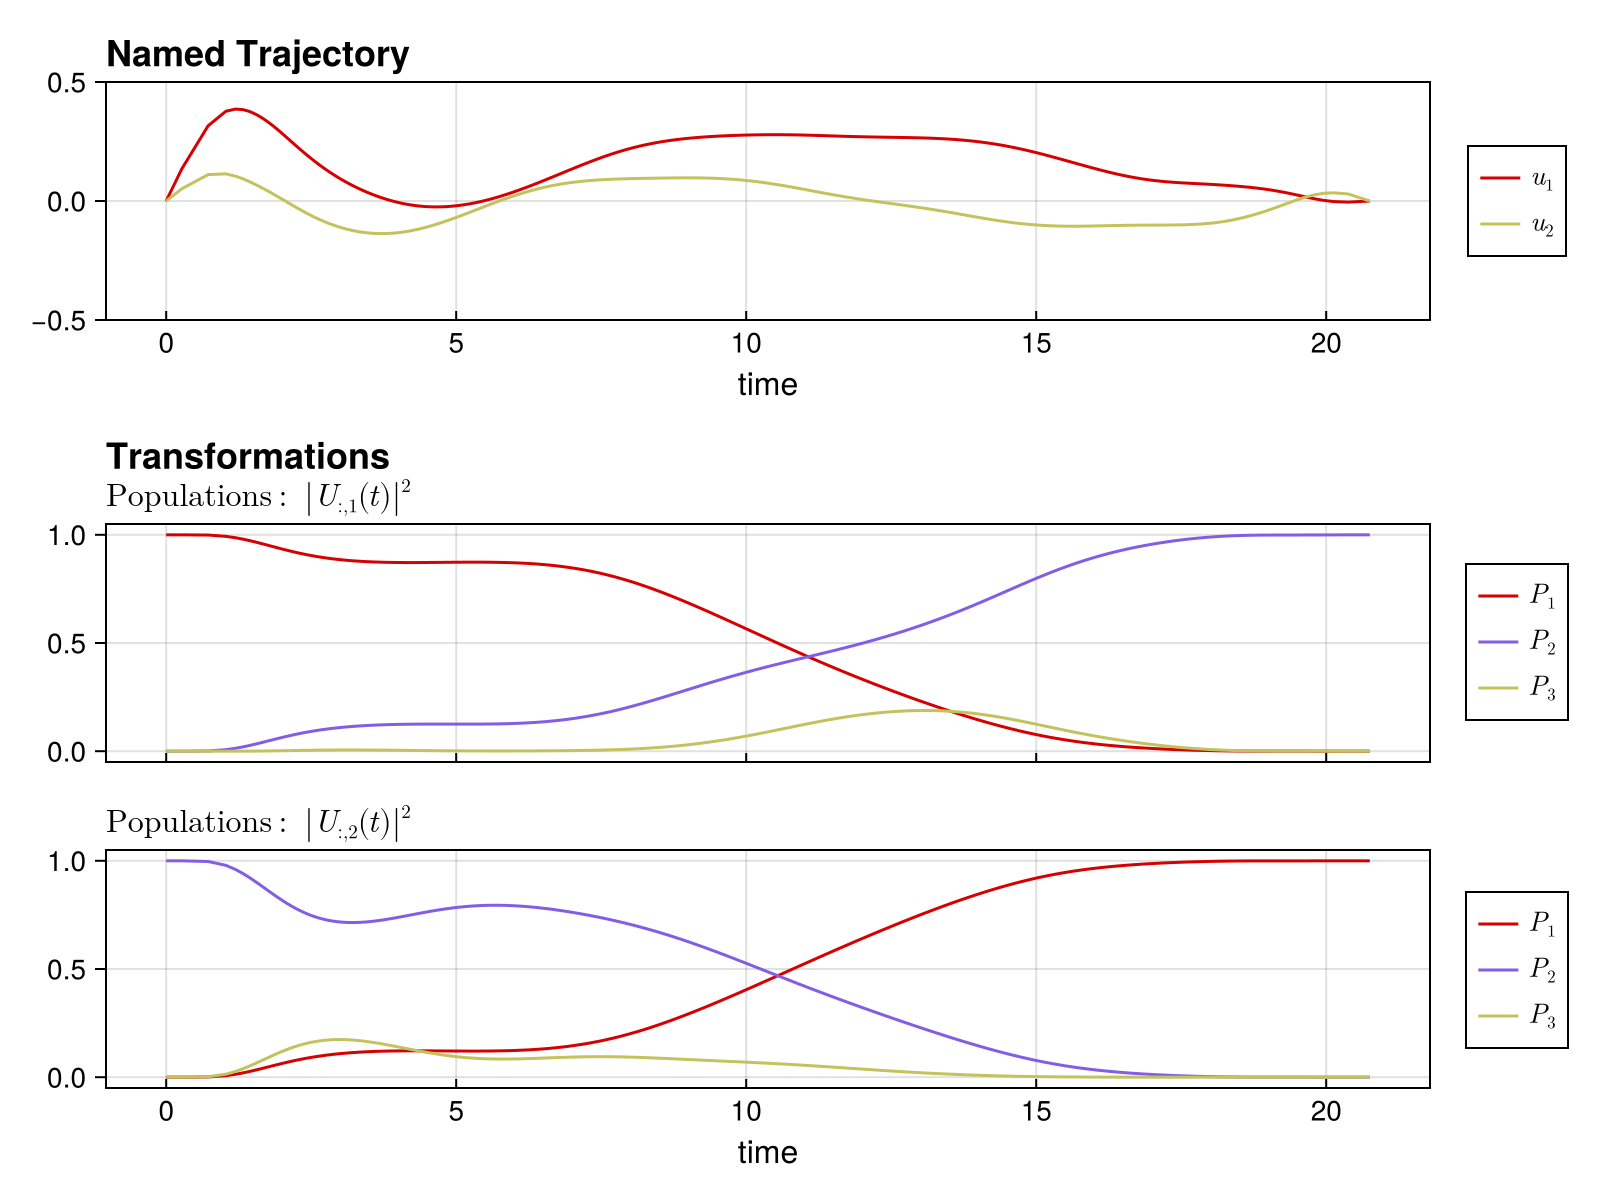

In [221]:
println(fidelity(qcp))
plot_unitary_populations(get_trajectory(qcp))